In [1]:
import sys
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread("C://Users//ACER//Desktop//materiopencv//cico.jpg")
#BISA DIUBAH DENGAN FOTO APAPUN YANG INGIN DISESUAIKAN KONTRAS DAN KECERAHANNYA SERTA FILTER GAUSSIAN BLUR

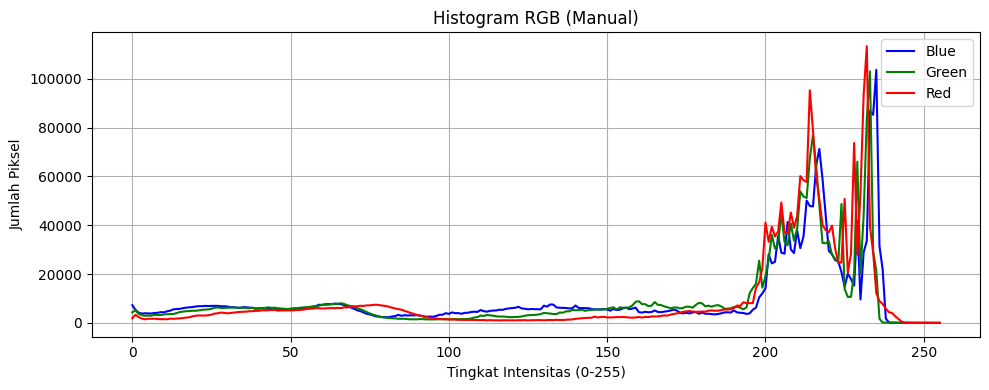

In [10]:
#PENGELOMPOKAN CHANNEL BIRU, HIJAU, DAN MERAH PADA CITRA
blue_channel  = img[:, :, 0]
green_channel = img[:, :, 1]
red_channel   = img[:, :, 2]

hist_b = np.zeros(256, dtype=int)
hist_g = np.zeros(256, dtype=int)
hist_r = np.zeros(256, dtype=int)

#INTENSITAS RGB CITRA (0-255)
height, width, _ = img.shape
for y in range(height):
    for x in range(width):
        b = blue_channel[y, x]
        g = green_channel[y, x]
        r = red_channel[y, x]
        hist_b[b] += 1
        hist_g[g] += 1
        hist_r[r] += 1

#HISTOGRAM CITRA
plt.figure(figsize=(10, 4))
plt.plot(hist_b, color='blue', label='Blue')
plt.plot(hist_g, color='green', label='Green')
plt.plot(hist_r, color='red', label='Red')
plt.title('Histogram RGB (Manual)')
plt.xlabel('Tingkat Intensitas (0-255)')
plt.ylabel('Jumlah Piksel')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## PENYESUAIAN KONTRAS DAN KECERAHAN CITRA DENGAN MENGGUNAKAN TRACKBAR

In [11]:
cv2.namedWindow('Penyesuaian Kontras Dan Kecerahan Citra')

def nothing(x):
    pass

cv2.createTrackbar('Kontras x0.1', 'Penyesuaian Kontras Dan Kecerahan Citra', 10, 30, nothing)  
cv2.createTrackbar('Kecerahan', 'Penyesuaian Kontras Dan Kecerahan Citra', 50, 100, nothing) 

while True:
    
    alpha = cv2.getTrackbarPos('Kontras x0.1', 'Penyesuaian Kontras Dan Kecerahan Citra') / 10 
    beta = cv2.getTrackbarPos('Kecerahan', 'Penyesuaian Kontras Dan Kecerahan Citra') - 50 
   
    adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
   
    cv2.imshow('Penyesuaian Kontras Dan Kecerahan Citra', adjusted)

    if cv2.waitKey(1) & 0xFF == 27:
        break
        
cv2.destroyAllWindows()
#DISARANKAN UNTUK MENGAKHIRI WINDOW TRACKBAR DENGAN TOMBOL ESC

## PENYESUAIAN GAUSSIAN BLUR CITRA DENGAN MENGGUNAKAN TRACKBAR

In [9]:
cv2.namedWindow('Filter Gaussian Blur Citra')

def nothing(x):
    pass

cv2.createTrackbar('Tingkat Blur', 'Filter Gaussian Blur Citra', 1, 20, nothing) 

while True:
    blur_value = cv2.getTrackbarPos('Tingkat Blur', 'Filter Gaussian Blur Citra')

    if blur_value % 2 == 0:
        blur_value += 1
    if blur_value < 1:
        blur_value = 1
        
    blurred = cv2.GaussianBlur(img, (blur_value, blur_value), 0)

    cv2.imshow('Filter Gaussian Blur Citra', blurred)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cv2.destroyAllWindows()
#DISARANKAN UNTUK MENGAKHIRI WINDOW TRACKBAR DENGAN TOMBOL ESC